# 2장 3강: 코호트 기반 리텐션 분석과 세그멘테이션 — 실습문제

## 실습 목표

- 분석 목적에 맞는 코호트 기준을 설정할 수 있다.
- 첫 유효 기능 사용 월을 기준으로 월간 코호트를 만들 수 있다.
- 코호트별 N개월 리텐션 테이블과 히트맵을 생성할 수 있다.
- 코호트와 세그먼트를 교차하여 그룹별 유지 패턴을 비교할 수 있다.
- 리텐션 차이를 근거로 개선 대상을 찾고 추가 분석 방향을 제안할 수 있다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- `ravenstack_subscriptions.csv`
- `ravenstack_feature_usage.csv`

Ravenstack은 구독형 B2B SaaS입니다. 이번 실습의 분석 질문은 다음과 같습니다.

> 제품 기능을 처음 사용한 구독이 이후 달에도 다시 기능을 사용하는가?

따라서 코호트 기준은 가입일이나 구독 시작일이 아니라 **첫 유효 기능 사용 월**로 설정합니다.

이번 실습에서 유효 기능 사용은 다음 조건을 모두 만족하는 기록입니다.

- `usage_date >= start_date`
- 종료일이 없거나 `usage_date <= end_date`

> 이번 실습의 월간 N개월 리텐션은 첫 유효 기능 사용 월로부터 정확히 N개월 뒤에 다시 기능을 사용한 구독의 비율입니다.

## 실습 준비

1. 필요한 라이브러리를 불러오세요.
2. 두 CSV 파일을 각각 `subscriptions`, `feature_usage`에 불러오세요.
3. 각 데이터의 행과 열 개수, 상위 5개 행을 확인하세요.
4. 분석 대상 컬럼의 자료형과 결측치 개수를 확인하세요.
5. `start_date`, `end_date`, `usage_date`를 날짜형으로 변환하세요.
6. 기능 사용 데이터와 구독 데이터를 `subscription_id`로 결합하여 `usage_with_sub`을 만드세요.
7. 구독 시작 전 사용 기록과 구독 종료 후 사용 기록의 개수를 확인하세요.
8. 유효 기능 사용 조건을 적용한 `valid_usage`를 만드세요.

In [1]:
# 실습 준비 코드를 작성하세요.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'


# ============================================================
# 1. 데이터 불러오기
# ============================================================

subscriptions = pd.read_csv('ravenstack_subscriptions.csv')

feature_usage = pd.read_csv('ravenstack_feature_usage.csv')


# ============================================================
# 2. 자료 구조 확인
# ============================================================

print('[자료 구조]')
print(f'{subscriptions.shape} | {feature_usage.shape}')


# ============================================================
# 3. 상위 5개 행 확인
# ============================================================

print('\n[subscriptions 상위 5개]')
display(subscriptions.head())


print('\n[feature_usage 상위 5개]')
display(feature_usage.head())


# ============================================================
# 4. 자료형 / 결측치 확인
# ============================================================

print('\n[자료형 - subscriptions]')
subscriptions.info()


print('\n[자료형 - feature_usage]')
feature_usage.info()


print('\n[결측치 개수 - subscriptions]')
print(subscriptions.isnull().sum()
)


print('\n[결측치 개수 - feature_usage]')
print(feature_usage.isnull().sum())


# ============================================================
# 5. 날짜형 변환
# ============================================================

subscriptions['start_date'] = pd.to_datetime(subscriptions['start_date'])

subscriptions['end_date'] = pd.to_datetime(subscriptions['end_date'])

feature_usage['usage_date'] = pd.to_datetime(feature_usage['usage_date'])


# 날짜형 변환 결과 확인
print('\n[날짜형 변환 결과]')
print(subscriptions[['start_date', 'end_date']].dtypes)
print(feature_usage['usage_date'].dtypes)


# ============================================================
# 고유 ID 개수 확인
# ============================================================

print('\n[고유 ID 개수]')

print('구독 ID 고유값 개수 :', subscriptions['subscription_id'].nunique())

print('기능 사용 이력 존재하는 고유 구독 ID :', feature_usage['subscription_id'].nunique())


# ============================================================
# 6. 기능 사용 데이터 + 구독 데이터 결합
# ============================================================

usage_with_sub = feature_usage.merge(subscriptions, on='subscription_id', how='left')


print('\n[결합 데이터 구조]')
print(usage_with_sub.shape)

display(usage_with_sub.head())


# ============================================================
# 7. 비정상 사용 기록 확인
# ============================================================

# 구독 시작 전에 발생한 기능 사용
before_start = (usage_with_sub['usage_date'] < usage_with_sub['start_date'])


# 구독 종료 후 발생한 기능 사용
# end_date가 존재하는 경우에만 비교
after_end = (usage_with_sub['end_date'].notna()) & (usage_with_sub['usage_date'] > usage_with_sub['end_date'])


print('\n[유효 기간 밖 사용 기록]')
print('구독 시작 전 사용 기록 :', before_start.sum())
print('구독 종료 후 사용 기록 :', after_end.sum())


# ============================================================
# 8. 유효 기능 사용 데이터 생성
# ============================================================

valid_condition = (

    # 구독 시작일 이후
    (usage_with_sub['usage_date']>= usage_with_sub['start_date'])
&
    # 종료일이 없거나 종료일 이전
    (usage_with_sub['end_date'].isna() | (usage_with_sub['usage_date']<= usage_with_sub['end_date']))
)


valid_usage = usage_with_sub[valid_condition].copy()


# ============================================================
# 유효 기능 사용 결과 확인
# ============================================================

print('\n[유효 기능 사용 데이터]')

print(
    '전체 기능 사용 기록 :',
    len(usage_with_sub)
)

print(
    '유효 기능 사용 기록 :',
    len(valid_usage)
)

print(
    '제외된 기능 사용 기록 :',
    len(usage_with_sub) - len(valid_usage)
)

print(
    '유효 기능 사용 구독 ID :',
    valid_usage['subscription_id'].nunique()
)


display(
    valid_usage.head()
)

[자료 구조]
(5000, 14) | (25000, 8)

[subscriptions 상위 5개]


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True



[feature_usage 상위 5개]


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False



[자료형 - subscriptions]
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   subscription_id    5000 non-null   str  
 1   account_id         5000 non-null   str  
 2   start_date         5000 non-null   str  
 3   end_date           486 non-null    str  
 4   plan_tier          5000 non-null   str  
 5   seats              5000 non-null   int64
 6   mrr_amount         5000 non-null   int64
 7   arr_amount         5000 non-null   int64
 8   is_trial           5000 non-null   bool 
 9   upgrade_flag       5000 non-null   bool 
 10  downgrade_flag     5000 non-null   bool 
 11  churn_flag         5000 non-null   bool 
 12  billing_frequency  5000 non-null   str  
 13  auto_renew_flag    5000 non-null   bool 
dtypes: bool(5), int64(3), str(6)
memory usage: 376.1 KB

[자료형 - feature_usage]
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature,account_id,start_date,...,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False,A-e08cd3,2024-11-23,...,Pro,67,3283,39396,False,False,False,False,annual,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False,A-c7ffc2,2023-09-22,...,Basic,30,570,6840,False,True,False,False,annual,True
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False,A-bbe56f,2024-10-15,...,Basic,22,418,5016,False,False,False,False,annual,True
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False,A-7f29a7,2024-11-24,...,Basic,41,779,9348,False,False,False,False,annual,True
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False,A-65a46c,2024-03-07,...,Basic,18,342,4104,False,False,False,False,monthly,True



[유효 기간 밖 사용 기록]
구독 시작 전 사용 기록 : 19142
구독 종료 후 사용 기록 : 290

[유효 기능 사용 데이터]
전체 기능 사용 기록 : 25000
유효 기능 사용 기록 : 5568
제외된 기능 사용 기록 : 19432
유효 기능 사용 구독 ID : 2651


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature,account_id,start_date,...,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False,A-65a46c,2024-03-07,...,Basic,18,342,4104,False,False,False,False,monthly,True
10,U-a7c89a,S-3673f2,2024-08-25,feature_36,9,2061,0,False,A-cd458b,2024-08-17,...,Enterprise,47,9353,112236,False,False,False,False,annual,True
19,U-138675,S-813cdc,2023-07-30,feature_37,5,960,0,False,A-39b19f,2023-07-04,...,Pro,20,980,11760,False,False,False,False,annual,True
20,U-77404d,S-6c969d,2024-08-31,feature_3,9,5022,0,False,A-855a48,2024-05-08,...,Basic,14,266,3192,False,False,False,False,monthly,False
22,U-25b56c,S-810c27,2024-10-06,feature_20,7,231,0,False,A-8ed5dd,2024-08-21,...,Basic,5,95,1140,False,False,False,False,annual,True


---

## 필수 1. 월별 코호트 리텐션 테이블 만들기

### 문제 1-1. 첫 기능 사용 이후에도 다시 제품을 사용하는가?

#### 문제 설명

각 구독의 첫 유효 기능 사용 월을 코호트로 설정하고, 이후 월별로 다시 기능을 사용한 구독의 비율을 계산하세요.

이번 문제에서는 2024년 1월부터 6월까지 시작한 코호트와 `Month 0`부터 `Month 6`까지의 리텐션을 확인합니다.

#### 요구사항

1. `valid_usage`에 기능 사용 월을 나타내는 `activity_month`를 만드세요.
2. 구독별 첫 `activity_month`를 구해 `cohort_month`로 추가하세요.
3. `activity_month - cohort_month`를 개월 수로 계산하여 `month_index`를 만드세요.
4. 코호트별 최초 구독 수를 `cohort_sizes`로 계산하세요.
5. `cohort_month`와 `month_index`별 고유 구독 수를 집계하세요.
6. 고유 구독 수를 `cohort_sizes`로 나누어 `retention_table`을 만드세요.
7. 2024년 1월~6월 코호트와 Month 0~6을 선택하여 백분율 표로 출력하세요.
8. 선택한 리텐션 테이블을 히트맵으로 시각화하세요.
9. 1월~6월 코호트 중 Month 1 리텐션이 가장 높은 코호트와 가장 낮은 코호트를 찾으세요.

#### 해석 질문

**Q1.** 이번 분석에서 첫 기능 사용 월을 코호트 기준으로 선택한 이유는 무엇인가요?  
**Q2.** Month 0 리텐션이 모두 100%인 이유는 무엇인가요?  
**Q3.** Month 1 리텐션이 가장 높은 코호트와 가장 낮은 코호트는 어디인가요?  
**Q4.** N개월 리텐션이 앞선 달보다 높아질 수도 있나요?

#### 제출 결과

- 코호트 및 `month_index` 생성 코드
- 월별 리텐션 테이블
- 리텐션 히트맵
- Month 1 리텐션 비교
- Q1~Q4 답변

,subscription_id,usage_date,activity_month,cohort_month,month_index
4,S-f9b1d0,2024-12-02,2024-12,2024-05,7
10,S-3673f2,2024-08-25,2024-08,2024-08,0
19,S-813cdc,2023-07-30,2023-07,2023-07,0
20,S-6c969d,2024-08-31,2024-08,2024-05,3
22,S-810c27,2024-10-06,2024-10,2024-10,0


[코호트별 구독 수]


cohort_month
2023-02      3
2023-03      6
2023-04     10
2023-05      6
2023-06     13
2023-07     33
2023-08     30
2023-09     38
2023-10     48
2023-11     58
2023-12     68
2024-01     73
2024-02     89
2024-03    107
2024-04    106
2024-05    137
2024-06    150
2024-07    175
2024-08    220
2024-09    236
2024-10    314
2024-11    331
2024-12    400
Freq: M, Name: subscription_id, dtype: int64

[코호트별 활동 구독 수]


month_index,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
cohort_month,,,,,,,,,,,,,,,,,,,,,
2023-02,3.0,NaN,1.0,NaN,NaN,1.0,1.0,NaN,1.0,1.0,...,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,1.0,1.0
2023-03,6.0,2.0,1.0,NaN,NaN,2.0,NaN,NaN,2.0,1.0,...,NaN,NaN,2.0,3.0,NaN,1.0,NaN,3.0,2.0,1.0
2023-04,10.0,1.0,1.0,1.0,NaN,2.0,2.0,1.0,1.0,NaN,...,2.0,1.0,NaN,3.0,NaN,NaN,NaN,NaN,3.0,NaN
2023-05,6.0,NaN,2.0,2.0,1.0,3.0,1.0,NaN,1.0,NaN,...,3.0,2.0,NaN,NaN,2.0,3.0,NaN,2.0,NaN,NaN
2023-06,13.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,2.0,3.0,...,3.0,NaN,3.0,2.0,2.0,2.0,1.0,NaN,NaN,NaN
2023-07,33.0,8.0,6.0,8.0,5.0,9.0,3.0,10.0,6.0,7.0,...,2.0,6.0,5.0,13.0,5.0,6.0,NaN,NaN,NaN,NaN
2023-08,30.0,5.0,10.0,8.0,6.0,7.0,4.0,4.0,6.0,3.0,...,3.0,4.0,7.0,7.0,6.0,NaN,NaN,NaN,NaN,NaN
2023-09,38.0,6.0,4.0,3.0,8.0,6.0,7.0,5.0,7.0,2.0,...,2.0,6.0,3.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN
2023-10,48.0,14.0,11.0,11.0,7.0,14.0,6.0,7.0,5.0,4.0,...,9.0,9.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


[월별 리텐션 테이블]


,Month 0,Month 1,Month 2,Month 3,Month 4,Month 5,Month 6
2024-01,100.0%,15.1%,16.4%,19.2%,20.5%,16.4%,19.2%
2024-02,100.0%,21.3%,16.9%,15.7%,7.9%,23.6%,28.1%
2024-03,100.0%,22.4%,22.4%,20.6%,19.6%,10.3%,21.5%
2024-04,100.0%,17.9%,27.4%,19.8%,19.8%,16.0%,15.1%
2024-05,100.0%,18.2%,19.7%,16.8%,21.2%,19.7%,15.3%
2024-06,100.0%,28.0%,12.0%,16.0%,20.0%,15.3%,21.3%


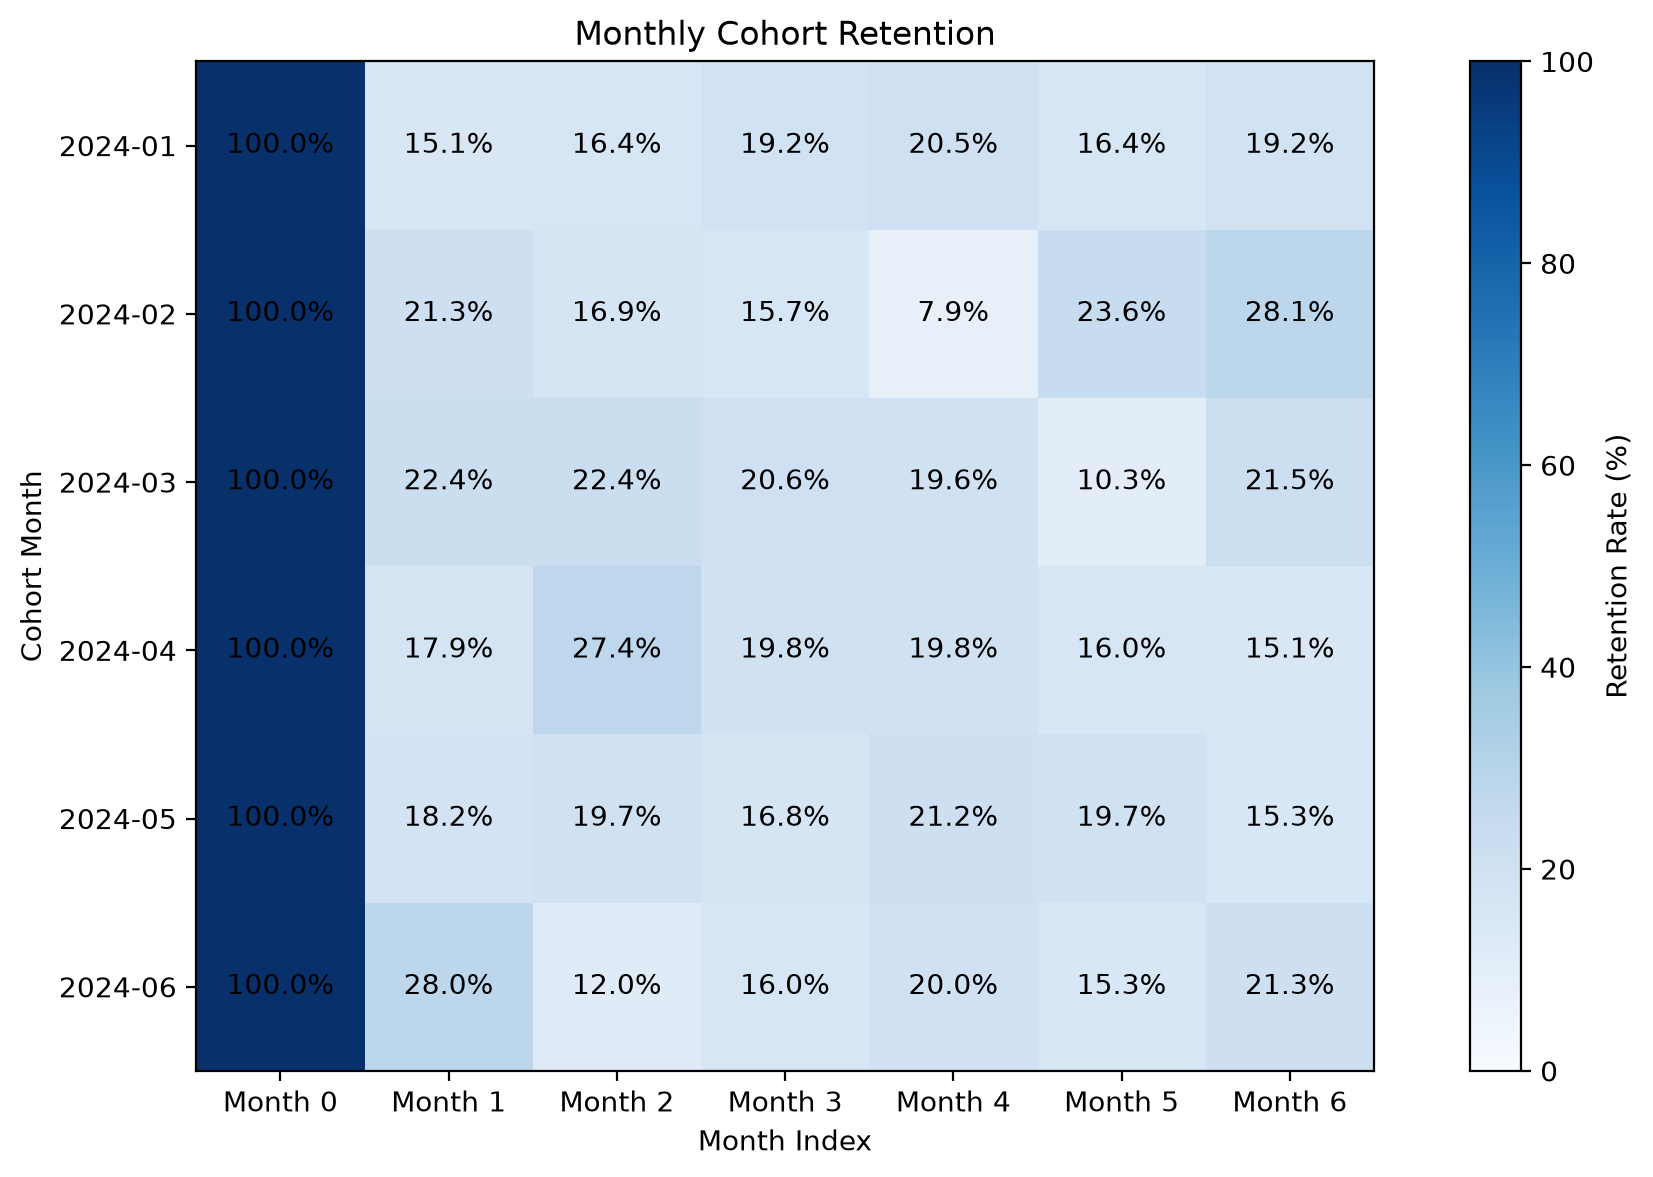

[Month 1 리텐션]


2024-01    15.1
2024-02    21.3
2024-03    22.4
2024-04    17.9
2024-05    18.2
2024-06    28.0
Freq: M, Name: Month 1, dtype: float64

===== Month 1 리텐션 비교 =====
가장 높은 코호트 : 2024-06
리텐션 : 28.0%

가장 낮은 코호트 : 2024-01
리텐션 : 15.1%


In [2]:
# ============================================================
# 1. 월별 코호트 리텐션 분석
# ============================================================

# ------------------------------------------------------------
# 1) 기능 사용 월 만들기
# ------------------------------------------------------------

valid_usage["activity_month"] = valid_usage["usage_date"].dt.to_period("M")


# ------------------------------------------------------------
# 2) 구독별 첫 기능 사용 월 만들기
# ------------------------------------------------------------

first_month = valid_usage.groupby("subscription_id")["activity_month"].min()


valid_usage["cohort_month"] = valid_usage["subscription_id"].map(first_month)


# ------------------------------------------------------------
# 3) Month 0, Month 1, Month 2 ... 만들기
# ------------------------------------------------------------

valid_usage["month_index"] = (
    (valid_usage["activity_month"].dt.year - valid_usage["cohort_month"].dt.year) * 12
    +
    (valid_usage["activity_month"].dt.month - valid_usage["cohort_month"].dt.month)
)


# 결과 확인
display(
    valid_usage[
        [
            "subscription_id",
            "usage_date",
            "activity_month",
            "cohort_month",
            "month_index"
        ]
    ].head()
)


# ============================================================
# 4. 코호트별 최초 구독 수
# ============================================================

cohort_sizes = (
    valid_usage
    .groupby("cohort_month")["subscription_id"]
    .nunique()
)

print("[코호트별 구독 수]")
display(cohort_sizes)


# ============================================================
# 5. 코호트별 / Month별 고유 구독 수
# ============================================================

cohort_counts = (
    valid_usage
    .groupby(["cohort_month", "month_index"])["subscription_id"]
    .nunique()
    .unstack()
)

print("[코호트별 활동 구독 수]")
display(cohort_counts)


# ============================================================
# 6. 리텐션 계산
# ============================================================

retention_table = (
    cohort_counts
    .div(cohort_sizes, axis=0)
)


# ============================================================
# 7. 2024년 1월 ~ 6월
#    Month 0 ~ Month 6 선택
# ============================================================

cohorts = pd.period_range(
    "2024-01",
    "2024-06",
    freq="M"
)

retention_table = retention_table.reindex(
    index=cohorts,
    columns=range(7)
)


# 컬럼 이름 변경
retention_table.columns = [
    "Month 0",
    "Month 1",
    "Month 2",
    "Month 3",
    "Month 4",
    "Month 5",
    "Month 6"
]


# 백분율로 변경
retention_pct = (retention_table * 100).round(1)


print("[월별 리텐션 테이블]")

display(retention_pct.style.format("{:.1f}%"))


# ============================================================
# 8. 리텐션 히트맵
# ============================================================

plt.figure(figsize=(10, 6))

plt.imshow(
    retention_pct,
    cmap="Blues",
    vmin=0,
    vmax=100
)


# x축
plt.xticks(
    range(len(retention_pct.columns)),
    retention_pct.columns
)


# y축
plt.yticks(
    range(len(retention_pct.index)),
    retention_pct.index.astype(str)
)


# 각 칸에 % 표시
for i in range(len(retention_pct.index)):

    for j in range(len(retention_pct.columns)):

        value = retention_pct.iloc[i, j]

        if pd.notna(value):

            plt.text(
                j,
                i,
                f"{value:.1f}%",
                ha="center",
                va="center"
            )


plt.title("Monthly Cohort Retention")
plt.xlabel("Month Index")
plt.ylabel("Cohort Month")

plt.colorbar(label="Retention Rate (%)")

plt.tight_layout()
plt.show()


# ============================================================
# 9. Month 1 리텐션 비교
# ============================================================

month1 = retention_pct["Month 1"].dropna()

print("[Month 1 리텐션]")
display(month1)


# 가장 높은 코호트
highest_cohort = month1.idxmax()
highest_rate = month1.max()


# 가장 낮은 코호트
lowest_cohort = month1.idxmin()
lowest_rate = month1.min()


print("===== Month 1 리텐션 비교 =====")
print("가장 높은 코호트 :",highest_cohort)
print("리텐션 :",f"{highest_rate:.1f}%")
print()
print("가장 낮은 코호트 :", lowest_cohort)
print("리텐션 :", f"{lowest_rate:.1f}%")

### 필수 1 답변 작성란

- **Q1.** 이번 분석에서 첫 기능 사용 월을 코호트 기준으로 선택한 이유는 무엇인가요? 
    - 분석 목적이 제품의 핵심 기능을 처음 사용한 뒤 다시 사용하는지를 확인하는 것이기 때문
    - 실제 가치 경험의 시작점을 비교할 수 있음

- **Q2.** Month 0 리텐션이 모두 100%인 이유는 무엇인가요?  
    - 각 구독을 첫 기능 사용월에 배정했으므로 코호트에 포함된 모든 구독이 Month 0에서는 기능을 사용함. 

- **Q3.** Month 1 리텐션이 가장 높은 코호트와 가장 낮은 코호트는 어디인가요?  
    - 가장 높은 코호트는 2024년 6월(28%)
    - 가장 낮은 코호트는 2024년 1월(15%)

- **Q4.** N개월 리텐션이 앞선 달보다 높아질 수도 있나요?
    - 있다. 각 월에 기능을 사용했는지 따로 계산하기 때문에 한 달 쉬었다가 다음 달에 돌아온 구독이 있으면
    - 리텐션이 N개월 뒤에 높아질 수 있다.

---

## 필수 2. 요금제별 Month 1 리텐션 비교하기

### 문제 2-1. 어떤 요금제의 초기 유지율이 상대적으로 낮은가?

#### 문제 설명

2024년 1월부터 6월까지 첫 기능 사용을 시작한 구독을 대상으로 요금제별 Month 1 리텐션을 비교하세요.

이 문제는 **코호트 기준과 속성 기반 세그먼트인 `plan_tier`를 교차하여 분석**하는 문제입니다.

#### 요구사항

1. 구독별 `cohort_month`, `plan_tier`를 한 행으로 정리한 `cohort_base`를 만드세요.
2. 2024년 1월~6월 코호트만 `selected_base`에 저장하세요.
3. 요금제별 코호트 구독 수를 계산하세요.
4. `month_index == 1`인 기록을 이용해 요금제별 Month 1 재사용 구독 수를 계산하세요.
5. 두 값을 나누어 `plan_retention`을 만드세요.
6. Month 1 리텐션이 낮은 순서로 정렬하고 백분율로 출력하세요.
7. 요금제별 Month 1 리텐션을 막대그래프로 시각화하세요.
8. 가장 낮은 요금제를 찾아 개선 방향과 추가 확인 데이터를 제안하세요.

#### 해석 질문

**Q1.** 이 분석에서 `plan_tier`는 어떤 세그멘테이션 기준인가요?  
**Q2.** Month 1 리텐션이 가장 낮은 요금제는 무엇인가요?  
**Q3.** 전체 리텐션만 보는 것보다 요금제별로 나누어 보는 것이 유용한 이유는 무엇인가요?  
**Q4.** 요금제별 차이만으로 낮은 리텐션의 원인을 확정할 수 있나요?

#### 제출 결과

- `cohort_base`와 `selected_base`
- `plan_retention` 결과
- 요금제별 리텐션 그래프
- 개선 방향과 추가 확인 데이터
- Q1~Q4 답변

[cohort_base]


,subscription_id,cohort_month,plan_tier
4,S-f9b1d0,2024-05,Basic
10,S-3673f2,2024-08,Enterprise
19,S-813cdc,2023-07,Pro
20,S-6c969d,2024-05,Basic
22,S-810c27,2024-10,Basic


[2024년 1월 ~ 6월 코호트]


,subscription_id,cohort_month,plan_tier
4,S-f9b1d0,2024-05,Basic
20,S-6c969d,2024-05,Basic
37,S-8b52b5,2024-03,Enterprise
50,S-e7e4bd,2024-06,Enterprise
101,S-34b845,2024-05,Pro


[요금제별 코호트 구독 수]


plan_tier
Basic         223
Enterprise    220
Pro           219
Name: subscription_id, dtype: int64

[요금제별 Month 1 재사용 구독 수]


plan_tier
Basic         42
Enterprise    50
Pro           48
Name: subscription_id, dtype: int64

[요금제별 Month 1 리텐션]


,cohort_size,month1_users,retention_rate,retention_pct
plan_tier,,,,
Basic,223,42,0.188341,18.8
Pro,219,48,0.219178,21.9
Enterprise,220,50,0.227273,22.7


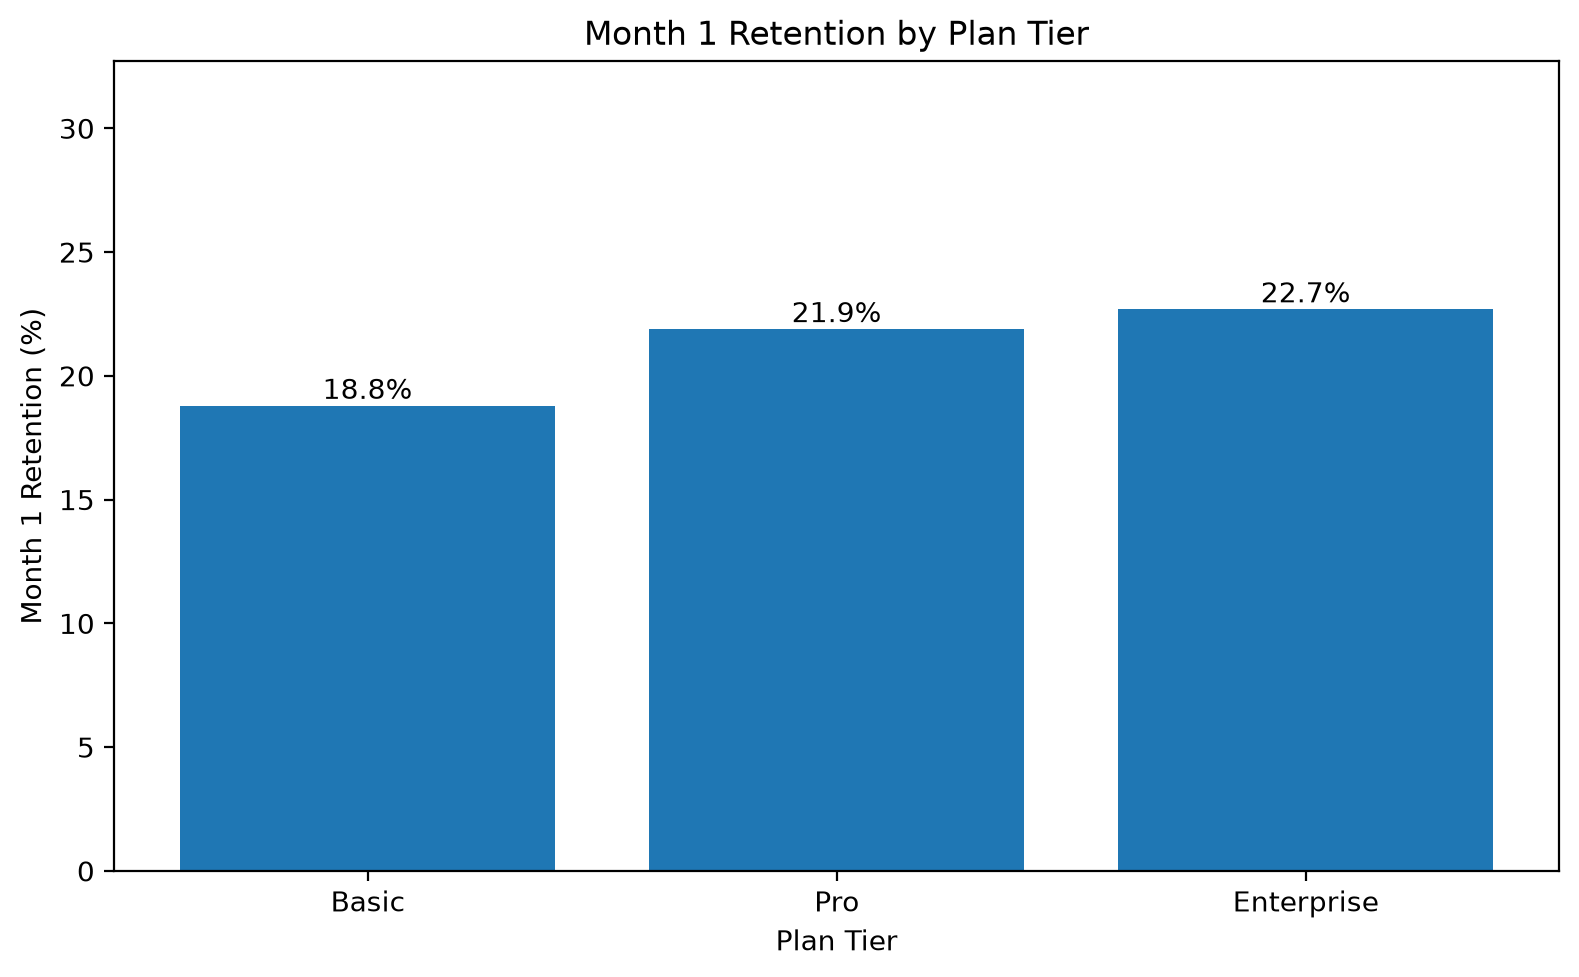

===== 가장 낮은 Month 1 리텐션 =====
요금제 : Basic
Month 1 Retention : 18.8%


In [3]:
# 필수 2 코드를 작성하세요.

# ============================================================
# 요금제별 Month 1 리텐션 비교
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. 구독별 cohort_month, plan_tier 한 행으로 정리
# ------------------------------------------------------------

cohort_base = (
    valid_usage[
        ["subscription_id", "cohort_month", "plan_tier"]
    ]
    .drop_duplicates("subscription_id")
)


print("[cohort_base]")
display(cohort_base.head())


# ------------------------------------------------------------
# 2. 2024년 1월 ~ 6월 코호트만 선택
# ------------------------------------------------------------

selected_base = cohort_base[
    (cohort_base["cohort_month"] >= pd.Period("2024-01"))
    &
    (cohort_base["cohort_month"] <= pd.Period("2024-06"))
].copy()


print("[2024년 1월 ~ 6월 코호트]")
display(selected_base.head())


# ------------------------------------------------------------
# 3. 요금제별 전체 코호트 구독 수
# ------------------------------------------------------------

plan_size = (
    selected_base
    .groupby("plan_tier")["subscription_id"]
    .nunique()
)


print("[요금제별 코호트 구독 수]")
display(plan_size)


# ------------------------------------------------------------
# 4. Month 1에 다시 사용한 구독 수
# ------------------------------------------------------------

month1_usage = valid_usage[
    valid_usage["month_index"] == 1
][
    ["subscription_id"]
].drop_duplicates()


# 2024년 1~6월 코호트와 연결
month1_users = selected_base.merge(
    month1_usage,
    on="subscription_id",
    how="inner"
)


# 요금제별 Month 1 재사용 구독 수
plan_month1 = (
    month1_users
    .groupby("plan_tier")["subscription_id"]
    .nunique()
)


print("[요금제별 Month 1 재사용 구독 수]")
display(plan_month1)


# ------------------------------------------------------------
# 5. Month 1 리텐션 계산
# ------------------------------------------------------------

plan_retention = pd.DataFrame({
    "cohort_size": plan_size,
    "month1_users": plan_month1
})


# Month 1 사용자가 없는 요금제가 있을 경우 0 처리
plan_retention["month1_users"] = (
    plan_retention["month1_users"]
    .fillna(0)
)


plan_retention["retention_rate"] = (
    plan_retention["month1_users"]
    / plan_retention["cohort_size"]
)


# ------------------------------------------------------------
# 6. 낮은 순서로 정렬 + 백분율
# ------------------------------------------------------------

plan_retention["retention_pct"] = (plan_retention["retention_rate"] * 100).round(1)


plan_retention = (
    plan_retention
    .sort_values("retention_rate")
)


print("[요금제별 Month 1 리텐션]")
display(plan_retention)


# ------------------------------------------------------------
# 7. 막대그래프
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

bars = plt.bar(
    plan_retention.index,
    plan_retention["retention_pct"]
)


# 막대 위 숫자 표시
for bar, value in zip(bars, plan_retention["retention_pct"]):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )


plt.title("Month 1 Retention by Plan Tier")
plt.xlabel("Plan Tier")
plt.ylabel("Month 1 Retention (%)")

plt.ylim(0, max(plan_retention["retention_pct"]) + 10)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. 가장 낮은 요금제 찾기
# ------------------------------------------------------------

lowest_plan = (
    plan_retention["retention_rate"]
    .idxmin()
)

lowest_rate = (
    plan_retention.loc[
        lowest_plan,
        "retention_pct"
    ]
)


print("===== 가장 낮은 Month 1 리텐션 =====")

print(
    "요금제 :",
    lowest_plan
)

print(
    "Month 1 Retention :",
    f"{lowest_rate:.1f}%"
)

### 필수 2 답변 작성란

- **Q1.** 이 분석에서 `plan_tier`는 어떤 세그멘테이션 기준인가요?  
    - 고객의 계약 요금제하는 특성을 기준으로 나누었다(속성 기반 세그멘테이션)

- **Q2.** Month 1 리텐션이 가장 낮은 요금제는 무엇인가요?  
    - Basic이며 약 18.8% 정도

- **Q3.** 전체 리텐션만 보는 것보다 요금제별로 나누어 보는 것이 유용한 이유는 무엇인가요?  
    - 전체 평균에 가려진 낮은 요금제 그룹을 찾아 개선 대상을 더 구체적으로 정할 수 있다.

- **Q4.** 요금제별 차이만으로 낮은 리텐션의 원인을 확정할 수 있나요?
    - 없다.
    - 요금제와 고객 규모, 기능 사용 유형, 지역별 차이 등 다은 요인이 있을 수 있으므로 추가 분석 필요

---

## 과제 1. 평가 문항 기반 독립 과제

### 문제 3-1. 코호트·결제 주기별 Month 1~3 리텐션 비교하기

#### 문제 설명

2024년 1월부터 6월까지의 첫 유효 기능 사용 월 코호트를 대상으로, 월간 결제 구독과 연간 결제 구독의 Month 1~3 리텐션을 비교하세요. 시간이 지나면서 유지율이 어떻게 변하는지 확인하고 개선 방향을 제안하세요.

> 필수 1의 월별 코호트 분석과 필수 2의 세그먼트별 비교 절차를 활용하는 문제입니다.

#### 요구사항

1. 구독별 cohort_month, billing_frequency를 한 행으로 정리하세요.
2. 2024년 1월~6월 코호트만 선택하고, 각 코호트의 Month 3까지 관찰 가능한지 확인하세요. 아직 관찰하지 못한 월은 리텐션을 0으로 처리하지 마세요.
3. 코호트·결제 주기별 최초 구독 수와 Month 1·2·3 각각의 고유 재사용 구독 수를 계산하세요. 같은 구독이 같은 달에 여러 번 사용해도 한 번만 세세요.
4. 다음 식으로 billing_retention을 만드세요.
- 리텐션 = 해당 경과 월의 고유 재사용 구독 수 ÷ 해당 코호트·결제 주기의 최초 구독 수
- Month 1~3 모두 같은 최초 구독 수를 분모로 사용하세요.
- 이전 달에 사용하지 않았어도 해당 달에 다시 사용했다면 포함하세요.
5. 행은 코호트·결제 주기, 열은 Month 1~3인 리텐션 표를 만들고 백분율로 출력하세요.
6. 코호트별로 월간·연간 결제 구독의 Month 1~3 리텐션을 비교하는 선그래프를 그리세요.
7. 각 코호트에서 두 결제 주기의 Month 1 리텐션 차이와, 각 결제 주기의 Month 1→2 및 Month 2→3 변화폭을 %p로 계산하세요. 감소·유지·회복 등의 패턴을 실제 결과에 맞게 해석하세요.
8. 우선 점검할 코호트·결제 주기 조합을 선택하고, 수치 근거·가능한 원인 가설·개선 방향·추가 확인 데이터를 제안하세요. 원인 가설을 확인된 사실처럼 단정하지 마세요.

#### 해석 질문

**Q1.** 각 코호트에서 Month 1 리텐션이 더 낮은 결제 주기는 무엇이며, 두 결제 주기의 차이는 몇 %p인가요?

**Q2.** 코호트·결제 주기별 Month 1→2 및 Month 2→3 변화폭은 몇 %p이며, 어떤 유지 패턴이 나타나나요?

**Q3.** 우선 점검할 코호트·결제 주기는 무엇인가요? 수치 근거와 가능한 원인 가설, 개선 방향을 설명하세요.

**Q4.** 이 결과만으로 결제 주기가 낮은 리텐션의 원인이라고 판단할 수 있나요? 추가로 어떤 데이터를 확인해야 하나요?

#### 제출 결과

- 코호트·결제 주기별 최초 구독 수와 Month 1~3 고유 재사용 구독 수
- billing_retention 표와 리텐션 선그래프
- 결제 주기 간 차이와 경과 월별 변화폭(%p)
- 시간 경과에 따른 유지 패턴 해석
- 우선 점검 대상·원인 가설·개선 방향·추가 확인 데이터
- Q1~Q4 답변

[분석 대상 구독]


,subscription_id,cohort_month,billing_frequency
4,S-f9b1d0,2024-05,monthly
20,S-6c969d,2024-05,monthly
37,S-8b52b5,2024-03,monthly
50,S-e7e4bd,2024-06,annual
101,S-34b845,2024-05,monthly


마지막 관찰 가능 월 : 2024-12
[코호트 × 결제 주기별 최초 구독 수]


,cohort_month,billing_frequency,cohort_size
0,2024-01,annual,46
1,2024-01,monthly,27
2,2024-02,annual,39
3,2024-02,monthly,50
4,2024-03,annual,55
5,2024-03,monthly,52
6,2024-04,annual,49
7,2024-04,monthly,57
8,2024-05,annual,68
9,2024-05,monthly,69


[billing_retention]


,cohort_month,billing_frequency,cohort_size,month_index,reuse_users,max_observable_month,retention,retention_pct
0,2024-01,annual,46,1,6.0,11,0.130435,13.0
1,2024-01,annual,46,2,7.0,11,0.152174,15.2
2,2024-01,annual,46,3,10.0,11,0.217391,21.7
3,2024-01,monthly,27,1,5.0,11,0.185185,18.5
4,2024-01,monthly,27,2,5.0,11,0.185185,18.5
5,2024-01,monthly,27,3,4.0,11,0.148148,14.8
6,2024-02,annual,39,1,10.0,10,0.256410,25.6
7,2024-02,annual,39,2,5.0,10,0.128205,12.8
8,2024-02,annual,39,3,4.0,10,0.102564,10.3
9,2024-02,monthly,50,1,9.0,10,0.180000,18.0


[코호트 × 결제 주기별 리텐션]


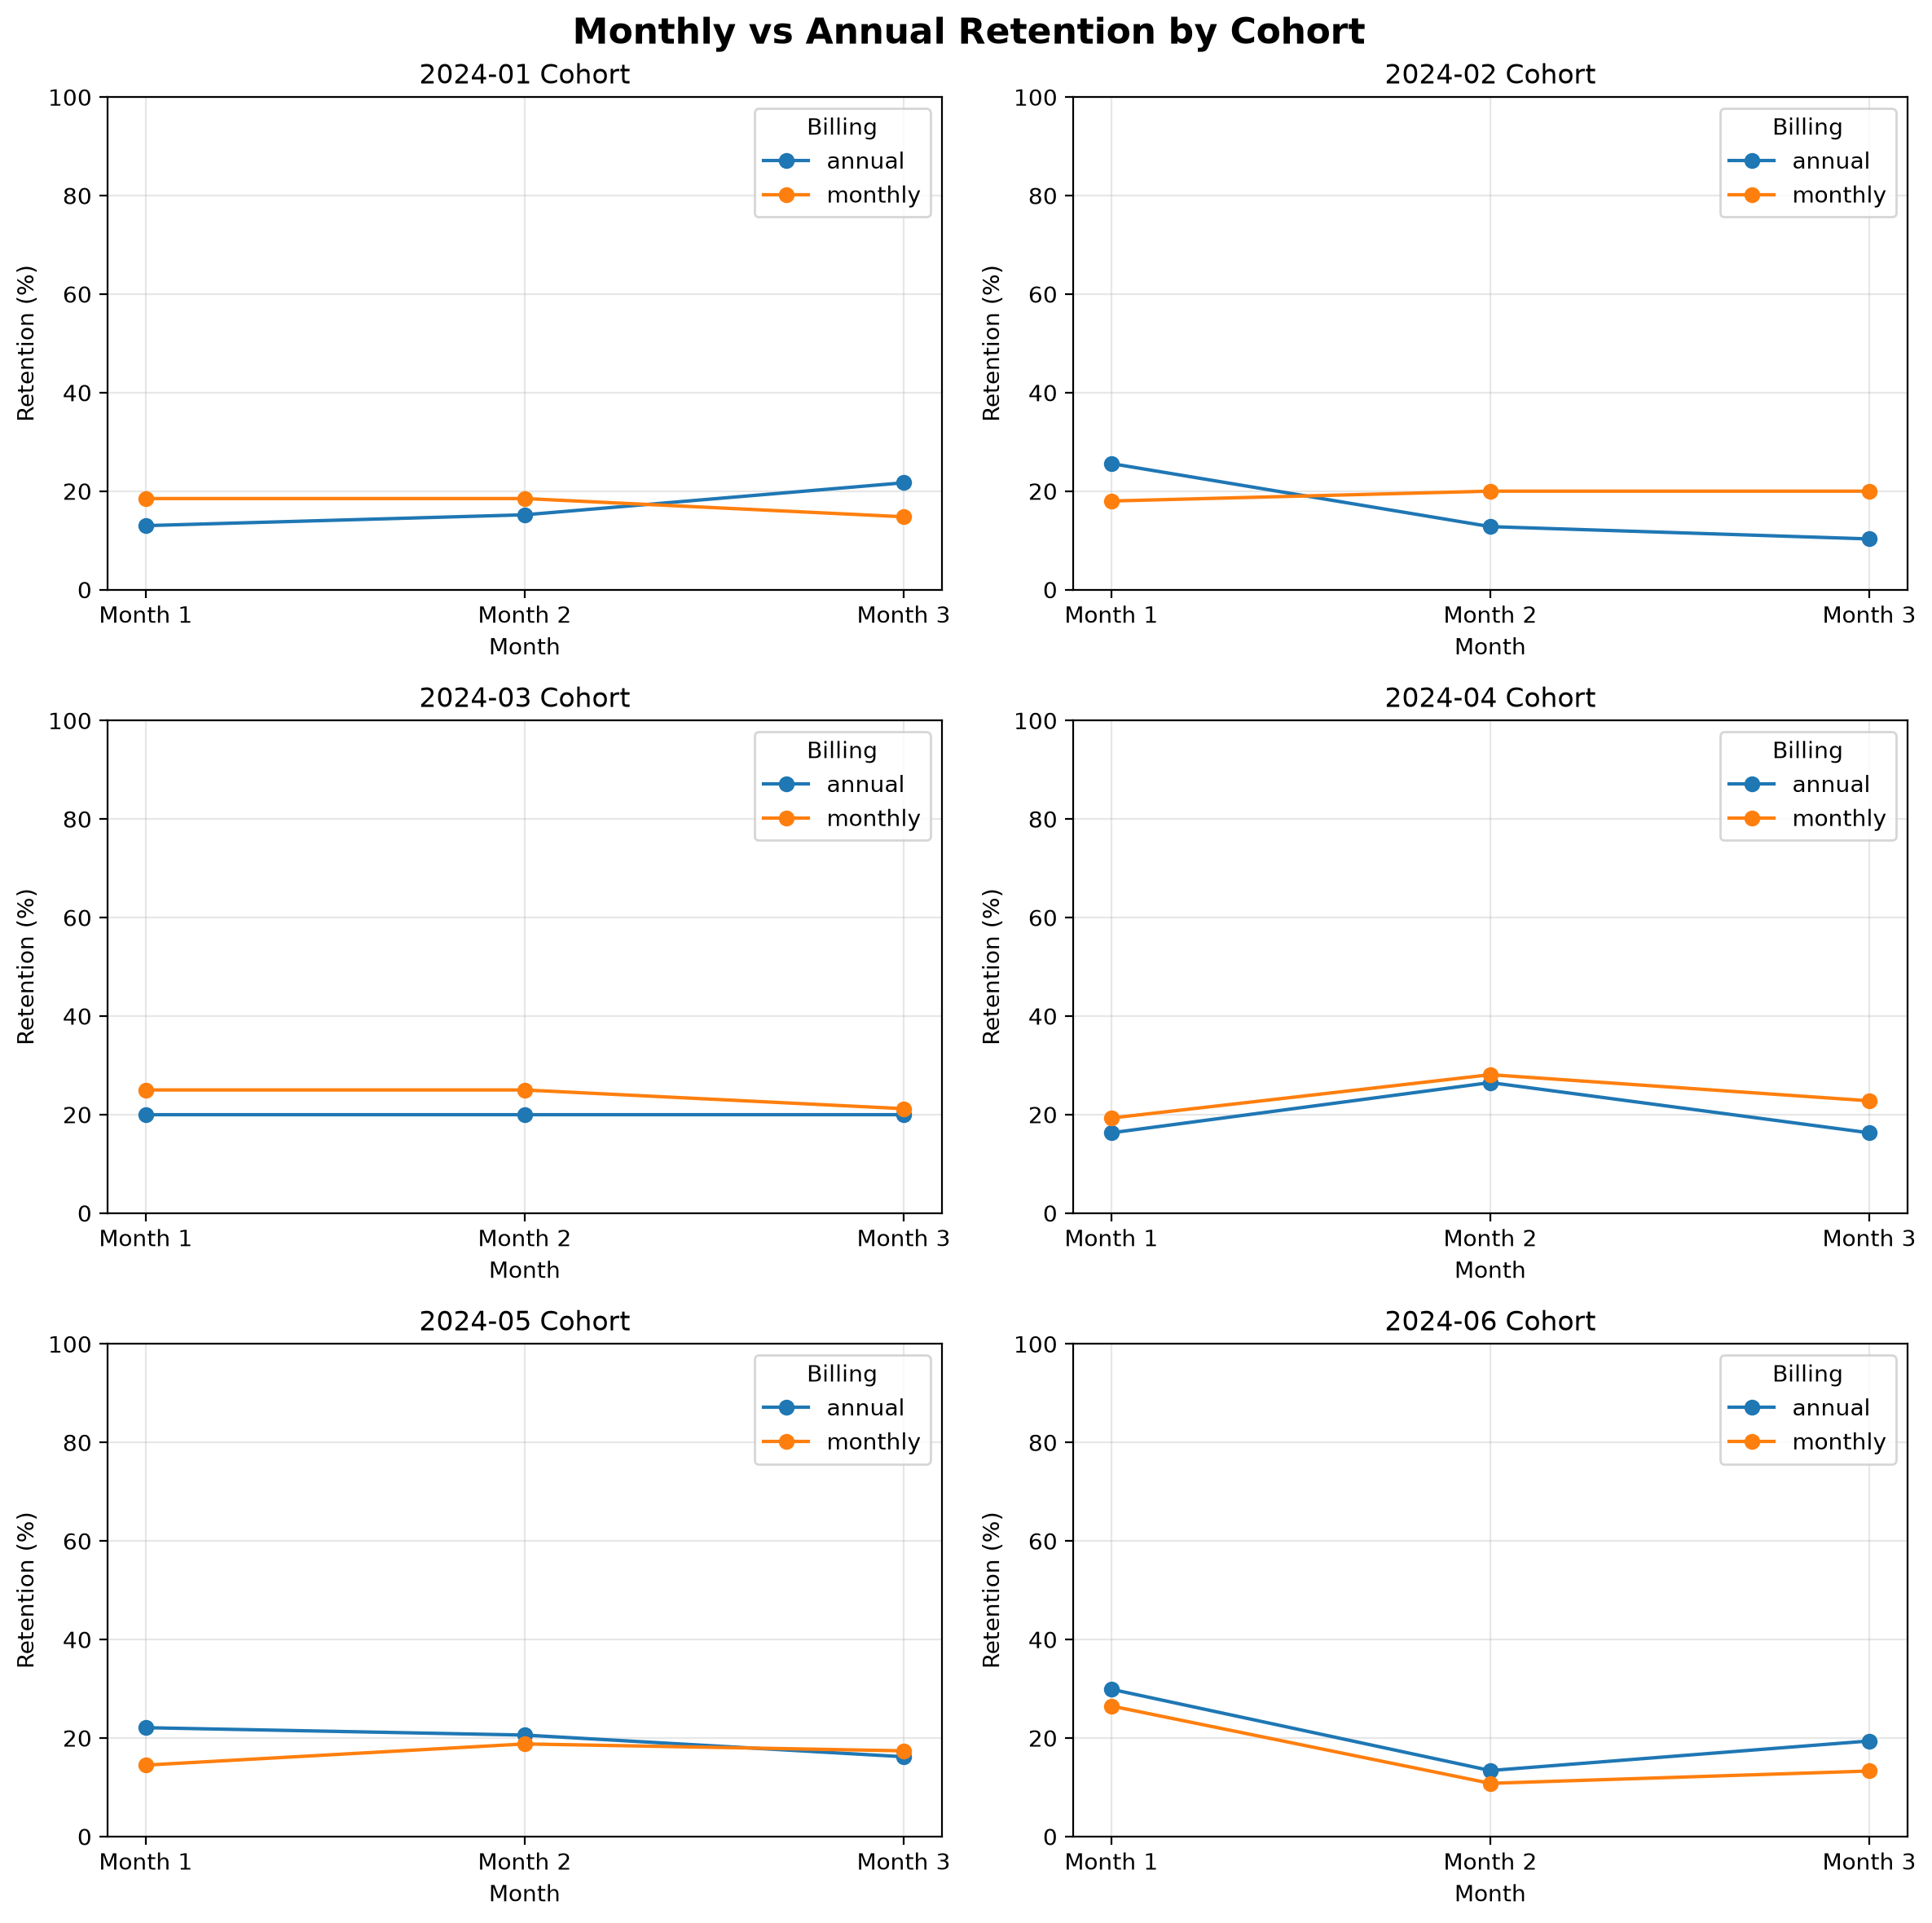

[Month 1 결제 주기별 차이]


billing_frequency,annual,monthly,monthly_annual_gap
cohort_month,,,
2024-01,13.0,18.5,5.5
2024-02,25.6,18.0,-7.6
2024-03,20.0,25.0,5.0
2024-04,16.3,19.3,3.0
2024-05,22.1,14.5,-7.6
2024-06,29.9,26.5,-3.4


[리텐션 변화폭 %p]


Month 1  Month 2  Month 3  Month1_to_2  \
cohort_month billing_frequency                                           
2024-01      annual                13.0     15.2     21.7          2.2   
             monthly               18.5     18.5     14.8          0.0   
2024-02      annual                25.6     12.8     10.3        -12.8   
             monthly               18.0     20.0     20.0          2.0   
2024-03      annual                20.0     20.0     20.0          0.0   
             monthly               25.0     25.0     21.2          0.0   
2024-04      annual                16.3     26.5     16.3         10.2   
             monthly               19.3     28.1     22.8          8.8   
2024-05      annual                22.1     20.6     16.2         -1.5   
             monthly               14.5     18.8     17.4          4.3   
2024-06      annual                29.9     13.4     19.4        -16.5   
             monthly               26.5     10.8     13.3        -15.7   

                                Month2_to_3  
cohort_month billing_frequency               
2024-01      annual                     6.5  
             monthly                   -3.7  
2024-02      annual                    -2.5  
             monthly                    0.0  
2024-03      annual                     0.0  
             monthly                   -3.8  
2024-04      annual                   -10.2  
             monthly                   -5.3  
2024-05      annual                    -4.4  
             monthly                   -1.4  
2024-06      annual                     6.0  
             monthly                    2.5

===== 우선 점검 대상 =====
코호트 : 2024-02
결제 주기 : annual
Month 3 Retention : 10.3%


In [ ]:
# 과제 1 코드를 작성하세요.

# ============================================================
# 과제 3-1
# 코호트 × 결제 주기별 Month 1~3 리텐션 비교
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. 구독별 cohort_month, billing_frequency 한 행으로 정리
# ============================================================

cohort_base = (
    valid_usage[
        ["subscription_id", "cohort_month", "billing_frequency"]
    ]
    .drop_duplicates("subscription_id")
)


# ============================================================
# 2. 2024년 1월 ~ 6월 코호트 선택
# ============================================================

selected_base = cohort_base[
    (cohort_base["cohort_month"] >= pd.Period("2024-01"))
    &
    (cohort_base["cohort_month"] <= pd.Period("2024-06"))
].copy()


print("[분석 대상 구독]")
display(selected_base.head())


# ============================================================
# Month 3까지 관찰 가능한지 확인
# ============================================================

# 데이터에서 확인 가능한 마지막 사용 월
last_month = valid_usage["activity_month"].max()

print("마지막 관찰 가능 월 :", last_month)


# 각 코호트가 몇 개월까지 관찰 가능한지 계산
selected_base["max_observable_month"] = (
    (last_month.year - selected_base["cohort_month"].dt.year) * 12
    +
    (last_month.month - selected_base["cohort_month"].dt.month)
)


# ============================================================
# 3. 코호트 × 결제 주기별 최초 구독 수
# ============================================================

cohort_size = (
    selected_base
    .groupby(
        ["cohort_month", "billing_frequency"]
    )["subscription_id"]
    .nunique()
    .reset_index(name="cohort_size")
)


print("[코호트 × 결제 주기별 최초 구독 수]")
display(cohort_size)


# ============================================================
# Month 1~3에 다시 사용한 고유 구독 수
# ============================================================

month_usage = valid_usage[
    valid_usage["month_index"].isin([1, 2, 3])
][
    ["subscription_id", "month_index"]
].drop_duplicates()


# 분석 대상 구독과 연결
month_usage = selected_base[
    ["subscription_id", "cohort_month", "billing_frequency"]
].merge(
    month_usage,
    on="subscription_id",
    how="inner"
)


# 고유 재사용 구독 수 계산
reuse_count = (
    month_usage
    .groupby(
        [
            "cohort_month",
            "billing_frequency",
            "month_index"
        ]
    )["subscription_id"]
    .nunique()
    .reset_index(name="reuse_users")
)


# ============================================================
# 4. 모든 코호트 × 결제 주기 × Month 1~3 조합 만들기
# ============================================================

rows = []

for _, row in cohort_size.iterrows():

    for month in [1, 2, 3]:

        rows.append({
            "cohort_month": row["cohort_month"],
            "billing_frequency": row["billing_frequency"],
            "cohort_size": row["cohort_size"],
            "month_index": month
        })


billing_retention = pd.DataFrame(rows)


# 재사용 구독 수 연결
billing_retention = billing_retention.merge(
    reuse_count,
    on=[
        "cohort_month",
        "billing_frequency",
        "month_index"
    ],
    how="left"
)


# ============================================================
# 관찰 가능한 Month만 0 처리
# 아직 관찰하지 못한 Month는 NaN 유지
# ============================================================

billing_retention["max_observable_month"] = (
    (last_month.year - billing_retention["cohort_month"].dt.year) * 12
    +
    (last_month.month - billing_retention["cohort_month"].dt.month)
)


# 관찰 가능하지만 사용자가 없으면 0명
observable = (
    billing_retention["month_index"]
    <= billing_retention["max_observable_month"]
)


billing_retention.loc[
    observable,
    "reuse_users"
] = (
    billing_retention.loc[
        observable,
        "reuse_users"
    ]
    .fillna(0)
)


# 아직 관찰할 수 없는 미래 Month는 NaN
billing_retention.loc[
    ~observable,
    "reuse_users"
] = np.nan


# ============================================================
# 리텐션 계산
# ============================================================

billing_retention["retention"] = (
    billing_retention["reuse_users"]
    / billing_retention["cohort_size"]
)


billing_retention["retention_pct"] = (
    billing_retention["retention"] * 100
).round(1)


print("[billing_retention]")
display(billing_retention)


# ============================================================
# 5. 리텐션 표 만들기
# 행 : cohort_month × billing_frequency
# 열 : Month 1 ~ 3
# ============================================================

retention_table = billing_retention.pivot(
    index=[
        "cohort_month",
        "billing_frequency"
    ],
    columns="month_index",
    values="retention_pct"
)


retention_table.columns = [
    "Month 1",
    "Month 2",
    "Month 3"
]


print("[코호트 × 결제 주기별 리텐션]")
display(
    retention_table.style.format(
        "{:.1f}%",
        na_rep="-"
    )
)


# ============================================================
# 6. 코호트별 Monthly / Annual 선그래프 (3 x 2)
# ============================================================

cohorts = retention_table.index.get_level_values(
    "cohort_month"
).unique()

fig, axes = plt.subplots(
    3, 2,
    figsize=(12, 12)
)

# 2차원 axes를 1차원으로 변경
axes = axes.flatten()


# 코호트별 그래프
for i, cohort in enumerate(cohorts):

    ax = axes[i]

    # 해당 코호트 데이터
    cohort_data = retention_table.loc[cohort]


    # monthly / annual 각각 선그래프
    for billing in cohort_data.index:

        values = cohort_data.loc[billing]

        ax.plot(
            ["Month 1", "Month 2", "Month 3"],
            values,
            marker="o",
            label=billing
        )


    # 제목
    ax.set_title(f"{cohort} Cohort")

    # y축
    ax.set_ylim(0, 100)

    ax.set_xlabel("Month")
    ax.set_ylabel("Retention (%)")

    # 격자
    ax.grid(alpha=0.3)

    # 범례
    ax.legend(title="Billing")


# 전체 제목
fig.suptitle(
    "Monthly vs Annual Retention by Cohort",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ============================================================
# 7-1. 코호트별 Monthly vs Annual
#      Month 1 리텐션 차이
# ============================================================

month1_compare = (
    billing_retention[
        billing_retention["month_index"] == 1
    ]
    .pivot(
        index="cohort_month",
        columns="billing_frequency",
        values="retention_pct"
    )
)


# monthly - annual 차이
if (
    "monthly" in month1_compare.columns
    and
    "annual" in month1_compare.columns
):

    month1_compare["monthly_annual_gap"] = (
        month1_compare["monthly"]
        - month1_compare["annual"]
    )


print("[Month 1 결제 주기별 차이]")
display(month1_compare)


# ============================================================
# 7-2. 각 결제 주기의 Month 1 → 2 / Month 2 → 3 변화폭
# ============================================================

change_table = retention_table.copy()
change_table["Month1_to_2"] = change_table["Month 2"] - change_table["Month 1"]
change_table["Month2_to_3"] = change_table["Month 3"] - change_table["Month 2"]


print("[리텐션 변화폭 %p]")
display(change_table)


# ============================================================
# 8. 우선 점검 대상 찾기
# Month 3까지 관찰 가능한 그룹 중
# Month 3 리텐션이 가장 낮은 조합
# ============================================================

priority_data = billing_retention[
    (billing_retention["month_index"] == 3)
    &
    (billing_retention["retention"].notna())
].copy()


if len(priority_data) > 0:

    lowest_idx = priority_data["retention"].idxmin()

    priority = priority_data.loc[lowest_idx]


    print("===== 우선 점검 대상 =====")

    print("코호트 :", priority["cohort_month"])

    print("결제 주기 :", priority["billing_frequency"])

    print("Month 3 Retention :", f'{priority["retention_pct"]:.1f}%')

else:
    print("Month 3까지 관찰 가능한 코호트가 없습니다.")

### 과제 1 답변 작성란

- **Q1.** 각 코호트에서 Month 1 리텐션이 더 낮은 결제 주기는 무엇이며, 두 결제 주기의 차이는 몇 %p인가요?

|코호트|	Annual|	Monthly|	더 낮은 결제 주기|	차이|
|---|---|---|---|---|
|2024-01|	13.0%|	18.5%|	annual|	5.5%p|
|2024-02|	25.6%|	18.0%|	monthly|	7.6%p|
|2024-03|	20.0%|	25.0%|	annual|	5.0%p|
|2024-04|	16.3%|	19.3%|	annual|	3.0%p|
|2024-05|	22.1%|	14.5%|	monthly|	7.6%p|
|2024-06|	29.9%|	26.5%|	monthly	|3.4%p|

    - 2024-01(5.5%p 차이), 2024-03(5.0%p 차이), 2024-04(3.0%p 차이) 코호트에서는 annual이 더 낮았으며, 
    - 2024-02(7.6%p 차이), 2024-05(7.6%p 차이), 2024-06(3.4%p 차이) 코호트에서는 monthly가 더 낮았다. 

<br>

- **Q2.** 코호트·결제 주기별 Month 1→2 및 Month 2→3 변화폭은 몇 %p이며, 어떤 유지 패턴이 나타나나요?

| 코호트 | 결제 주기 | Month 1→2 | Month 2→3 |
|---|---|---:|---:|
| 2024-01 | annual | +2.2%p | +6.5%p |
| 2024-01 | monthly | 0.0%p | -3.7%p |
| 2024-02 | annual | -12.8%p | -2.5%p |
| 2024-02 | monthly | +2.0%p | 0.0%p |
| 2024-03 | annual | 0.0%p | 0.0%p |
| 2024-03 | monthly | 0.0%p | -3.8%p |
| 2024-04 | annual | +10.2%p | -10.2%p |
| 2024-04 | monthly | +8.8%p | -5.3%p |
| 2024-05 | annual | -1.5%p | -4.4%p |
| 2024-05 | monthly | +4.3%p | -1.4%p |
| 2024-06 | annual | -16.5%p | +6.0%p |
| 2024-06 | monthly | -15.7%p | +2.5%p |

    - 코호트, 결제주기별로 일정하게 유지 또는 감소가 일어나는 패턴은 존재하지 않는다.

- **Q3.** 우선 점검할 코호트·결제 주기는 무엇인가요? 수치 근거와 가능한 원인 가설, 개선 방향을 설명하세요.

    - 우선 점검할 대상은 2024-02 코호트의 annual 결제 고객이다.
    - 해당 코호트의  Month 3 리텐션은 10.3%로 가장 낮게 나타났다. 
    - Month 1→2에서 -12.8%p, Month 2→3에서 -2.5%p의 감소가 나타난 것은 첫 유료 기능 사용 이후 지속적인 사용으로 연결되지 못한 고객이 많았을 가능성이 있기 때문에 우선 점검이 필요하다.
    - 유료 기능 가입 이후 지속적으로 사용할만큼의 기능이 있지 않았을 가능성이 있다.
    - 이를 위해 해당 코호트 고객들을 대상으로 어떤 기능을 사용했는지 어느 부분에서 개선이 필요한지 파악이 필요하다.

- **Q4.** 이 결과만으로 결제 주기가 낮은 리텐션의 원인이라고 판단할 수 있나요? 추가로 어떤 데이터를 확인해야 하나요?
    - 이 결과만으로 판단할 수 없다. 
    - 결제주기와 리텐션의 차이는 확인 할 수 있지만 정확히 인과관계를 나타낼 수 없다.
    - 추가로 특정 시기에 이벤트, 제품 발매, 기업 규모 등의 데이터를 확인해야한다.


---

## 실습 마무리

아래 질문에 답하세요.

1. 이번 분석에서는 어떤 행동을 코호트의 출발점으로 사용했나요?
    - 구독별 첫 유효기능 사용 월을 출발점으로 사용했다.

2. 월간 N개월 리텐션은 어떻게 계산했나요?
    - 첫 기능 사용월로부터 N개월 뒤 기능을 다시 사용한 고유 구독 수를 해당 코호트의 최초 구독 수로 나누었다.

3. 코호트와 세그먼트를 함께 분석하면 어떤 장점이 있나요?
    - 같은 시기에 기능을 사용한 사용자 중에서도 어떤 특성의 그룹에서 유지(재방문율, 재구매율)이 낮은지 구체적으로 확인할 수 있다.

4. 어떤 세그먼트의 Month 1 리텐션이 상대적으로 낮았나요?
    - basic, 18.8% 정도로 가장 낮았다.

5. 리텐션 차이와 실제 원인을 왜 구분해야 하나요?
    - 리텐션 표는 어느 그룹이 낮은지는 보여주지만 요금제, 기능 경험, 고객특성 중 무엇이 원인인지는 직접적으로 알려주지는 않음.